**Load data and prepare**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

# Load RFM data
rfm = pd.read_csv("../output/rfm_segments.csv")

# Target — churn binary label
rfm["Churn"] = rfm["Segment"].apply(lambda x: 1 if x in ["At Risk", "Lost"] else 0)

# Features
X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Churn"]

# Scale — important for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Train: 3470 | Test: 868
Churn rate: 29.8%


**Train and evaluate**

In [2]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

      Active       0.94      0.97      0.95       610
     Churned       0.92      0.85      0.88       258

    accuracy                           0.93       868
   macro avg       0.93      0.91      0.92       868
weighted avg       0.93      0.93      0.93       868

ROC-AUC: 0.9816


**Coefficients**

In [3]:
coef_df = pd.DataFrame({
    "Feature": ["Recency", "Frequency", "Monetary"],
    "Coefficient": model.coef_[0],
    "Odds Ratio": np.exp(model.coef_[0])
}).round(4)

print(coef_df.to_string(index=False))

  Feature  Coefficient  Odds Ratio
  Recency       1.6265      5.0862
Frequency     -11.1488      0.0000
 Monetary      -9.6577      0.0001


**ROC Curve + Confusion Matrix**

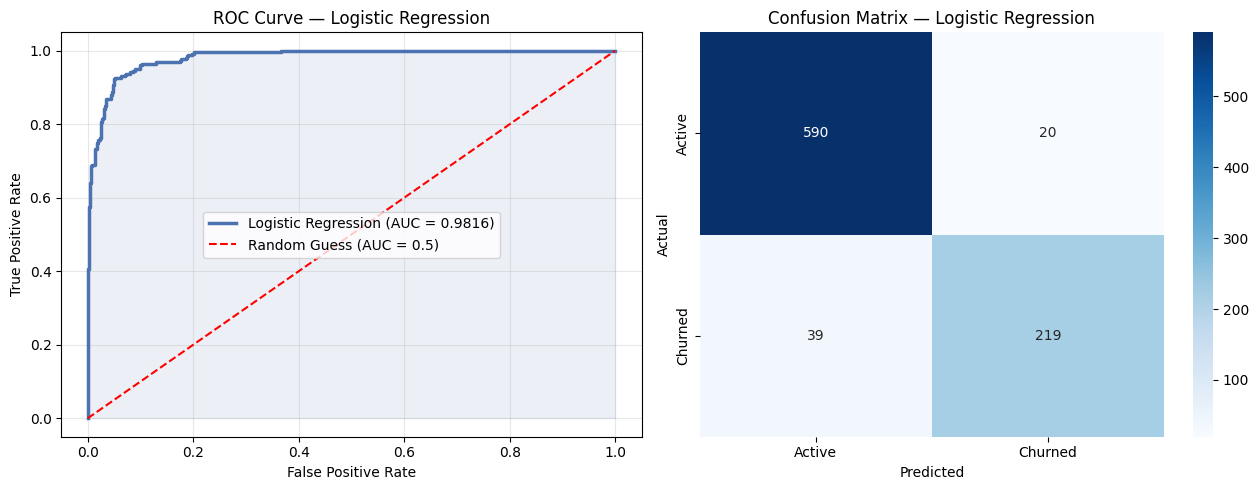

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color="#4C72B0", linewidth=2.5, label=f"Logistic Regression (AUC = {auc:.4f})")
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Random Guess (AUC = 0.5)")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#4C72B0")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Logistic Regression")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix — Logistic Regression")

plt.tight_layout()
plt.savefig("../output/logistic_regression_eval.png", dpi=150)
plt.show()

**Compare Logistic Regression vs Random Forest**

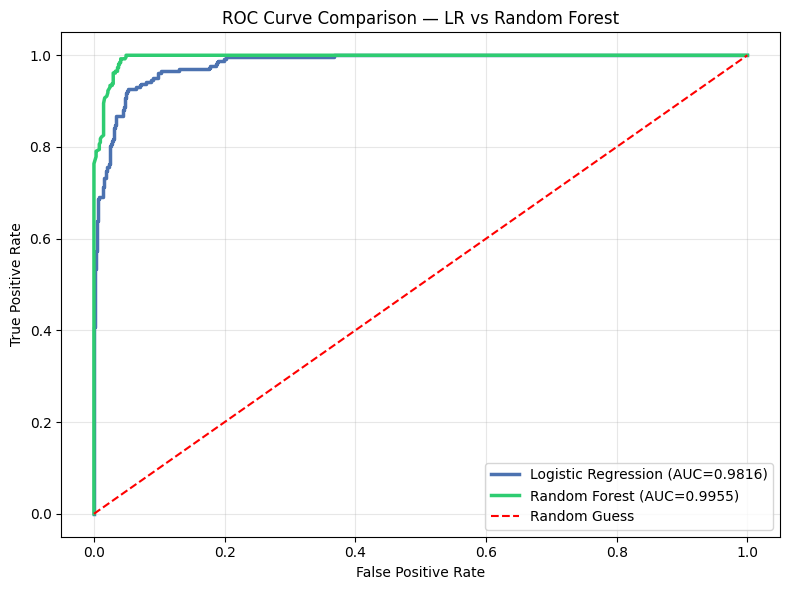

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest for comparison
rf = RandomForestClassifier(n_estimators=100, random_state=42)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf.fit(X_train_raw, y_train_raw)
rf_prob = rf.predict_proba(X_test_raw)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test_raw, rf_prob)

# Plot both ROC curves together
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#4C72B0", linewidth=2.5,
         label=f"Logistic Regression (AUC={auc:.4f})")
plt.plot(rf_fpr, rf_tpr, color="#2ecc71", linewidth=2.5,
         label=f"Random Forest (AUC={roc_auc_score(y_test_raw, rf_prob):.4f})")
plt.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — LR vs Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../output/roc_comparison.png", dpi=150)
plt.show()